In [35]:
# Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv("Clean_Amazon_Dataset.csv")

In [37]:
continuous_columns = [
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

# COVARIANCE

In [40]:
dataset[continuous_columns].cov()

,discounted_price,actual_price,discount_percentage,rating,rating_count
discounted_price,4.822336e+07,7.264202e+07,-36421.512162,243.652789,-8.035193e+06
actual_price,7.264202e+07,1.182619e+08,-27786.781962,385.687509,-1.670869e+07
discount_percentage,-3.642151e+04,-2.778678e+04,468.112393,-0.979537,1.025871e+04
rating,2.436528e+02,3.856875e+02,-0.979537,0.085016,1.264832e+03
rating_count,-8.035193e+06,-1.670869e+07,10258.707606,1264.832428,1.825631e+09


# CORRELATION

In [25]:
corr=dataset.select_dtypes(include=['number']).corr()
corr

,discounted_price,actual_price,discount_percentage,rating,rating_count
discounted_price,1.000000,0.961915,-0.242412,0.120335,-0.027081
actual_price,0.961915,1.000000,-0.118098,0.121636,-0.035959
discount_percentage,-0.242412,-0.118098,1.000000,-0.155273,0.011097
rating,0.120335,0.121636,-0.155273,1.000000,0.101526
rating_count,-0.027081,-0.035959,0.011097,0.101526,1.000000


In [ ]:
| Relationship                    | Correlation | Interpretation                    |
| ------------------------------- | ----------: | --------------------------------- |
| Discounted Price ↔ Actual Price |   **0.962** | Very strong positive relationship |
| Discounted Price ↔ Discount %   |  **-0.242** | Weak negative relationship        |
| Actual Price ↔ Discount %       |  **-0.118** | Very weak negative relationship   |
| Discounted Price ↔ Rating       |   **0.120** | Very weak positive relationship   |
| Actual Price ↔ Rating           |   **0.122** | Very weak positive relationship   |
| Discounted Price ↔ Rating Count |  **-0.027** | Almost no relationship            |
| Actual Price ↔ Rating Count     |  **-0.036** | Almost no relationship            |
| Discount % ↔ Rating             |  **-0.155** | Very weak negative relationship   |
| Discount % ↔ Rating Count       |   **0.011** | Almost no relationship            |
| Rating ↔ Rating Count           |   **0.102** | Very weak positive relationship   |


Actual price and discounted price are highly related, while price, discount, and rating have very weak linear relationships with customer demand 
(rating count). This indicates that no single numerical variable is sufficient to explain customer demand.

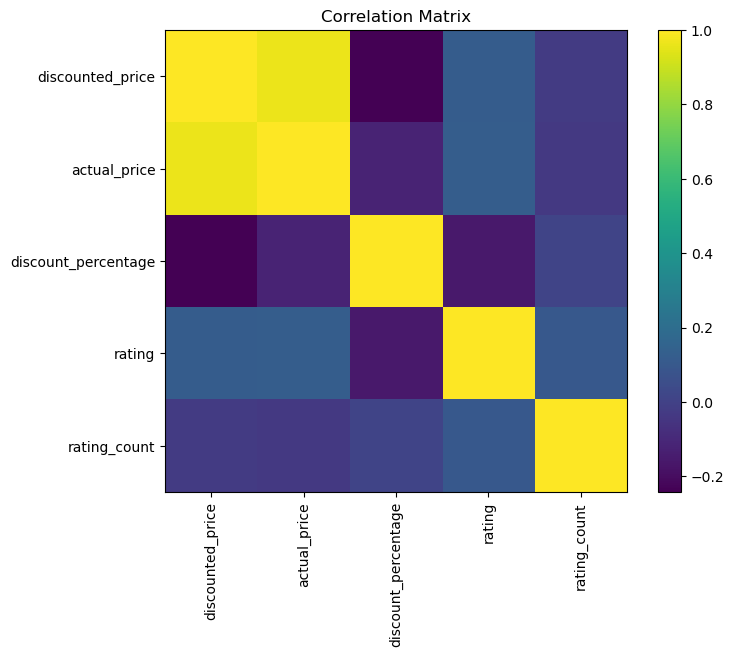

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()


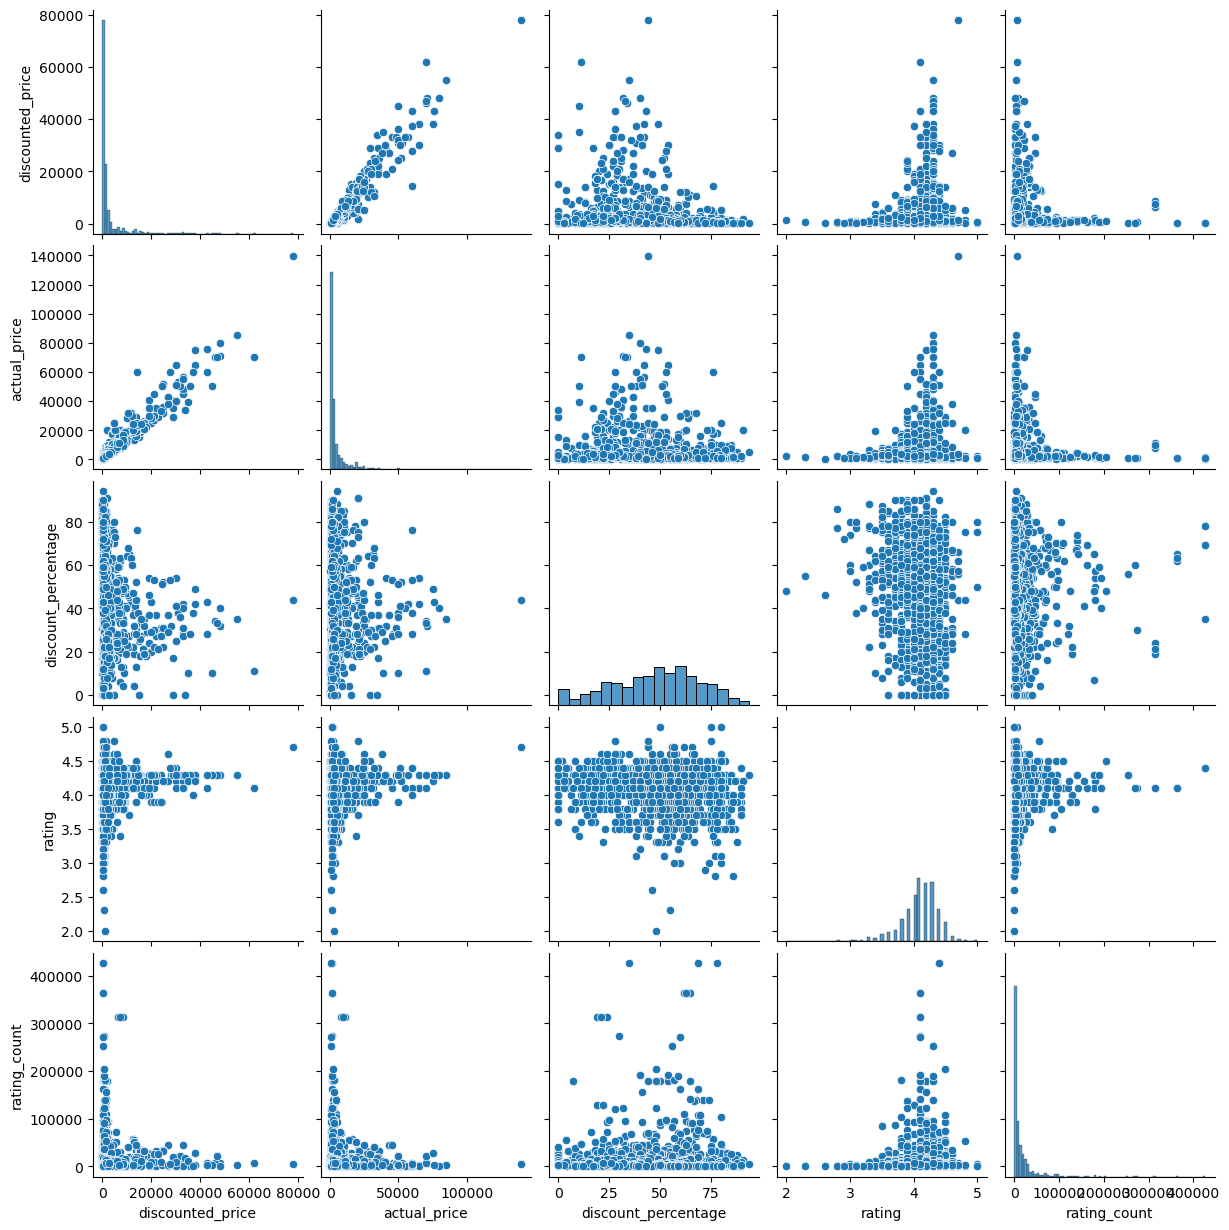

In [27]:
import seaborn as sns
sns.pairplot(dataset)

# Variance Inflation Factor (VIF) - Detect multicollinearity among independent variables.

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = dataset[
[
"discounted_price",
"actual_price",
"discount_percentage",
"rating",
"rating_count"
]
]

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
variance_inflation_factor(X.values,i)
for i in range(X.shape[1])
]

print(vif)

               Feature        VIF
0     discounted_price  20.493214
1         actual_price  20.384345
2  discount_percentage   7.058359
3               rating   7.274257
4         rating_count   1.192698


# Homoscedasticity / Heteroscedasticity

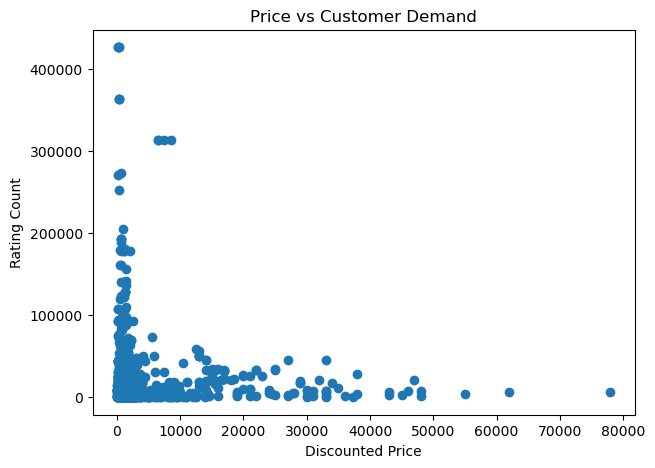

In [30]:
plt.figure(figsize=(7,5))

plt.scatter(
dataset["discounted_price"],
dataset["rating_count"]
)

plt.xlabel("Discounted Price")

plt.ylabel("Rating Count")

plt.title("Price vs Customer Demand")

plt.show()

# Independent T-Test

In [32]:
from scipy.stats import ttest_ind

high_discount = dataset[dataset["discount_percentage"]>=50]["rating"]
low_discount = dataset[dataset["discount_percentage"]<50]["rating"]

ttest_ind(
high_discount,
low_discount
)


TtestResult(statistic=np.float64(-4.243822824663262), pvalue=np.float64(2.3356014707998052e-05), df=np.float64(1463.0))

# Hypothesis Testing

1. Null Hypothesis (H₀): There is no significant difference in customer ratings between high-discount and low-discount products.

2. Alternative Hypothesis (H₁): There is a significant difference in customer ratings between high-discount and low-discount products.

In [33]:
if pvalue<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Reject Null Hypothesis


# ANOVA: statistical test used to determine whether the means of three or more groups are significantly different from each other.

Do customer ratings differ across major product categories

In [34]:
from scipy.stats import f_oneway

top_categories = dataset["category"].value_counts().head(5).index

groups = []

for category in top_categories:

    groups.append(
        dataset[
            dataset["category"]==category
        ]["rating"]
    )

stat,pvalue = f_oneway(*groups)

print("F Statistic :",stat)

print("P Value :",pvalue)

F Statistic : 19.358017990039198
P Value : 8.56003545387637e-15
